# IMPORTING FILES

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

import warnings

warnings.filterwarnings('ignore')

# ML
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose

# IMPORTING DATA

In [2]:
df = pd.read_csv("D:\MyFiles\Downloads\HHS_Unaccompanied_Alien_Children_Program - HHS_Unaccompanied_Alien_Children_Program (3).csv")
df

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,Year,Month No.,Week No.,Day No.
0,"December 21, 2025",6,18,11,"2,484",14,2025,12,52,7
1,"December 18, 2025",11,50,6,"2,472",16,2025,12,51,4
2,"December 17, 2025",7,31,11,"2,481",10,2025,12,51,3
3,"December 16, 2025",8,54,15,"2,468",9,2025,12,51,2
4,"December 15, 2025",11,42,9,"2,470",7,2025,12,51,1
...,...,...,...,...,...,...,...,...,...,...
715,"January 25, 2023",20,22,41,"7,538",180,2023,1,4,3
716,"January 24, 2023",47,42,47,"7,433",175,2023,1,4,2
717,"January 23, 2023",32,50,39,"7,280",181,2023,1,4,1
718,"January 22, 2023",32,49,39,"7,122",227,2023,1,4,7


# DATA CLEANING

In [3]:
# Strip whitespace from column names
df.columns = [col.strip() for col in df.columns]

# Convert Date to Datetime
df['Date'] = pd.to_datetime(df['Date'])

cols_to_clean = [
    'Children apprehended and placed in CBP custody*', 
    'Children in CBP custody', 
    'Children transferred out of CBP custody', 
    'Children in HHS Care', 
    'Children discharged from HHS Care'
]

for col in cols_to_clean:
    if df[col].dtype == 'object':
        df[col] = df[col].str.replace(',', '').astype(float)

# Sort by Date
df = df.sort_values('Date').set_index('Date')

print("Data Cleaned. Types:")
print(df.dtypes)

Data Cleaned. Types:
Children apprehended and placed in CBP custody*      int64
Children in CBP custody                              int64
Children transferred out of CBP custody              int64
Children in HHS Care                               float64
Children discharged from HHS Care                    int64
Year                                                 int64
Month No.                                            int64
Week No.                                             int64
Day No.                                              int64
dtype: object


# RESAMPLING TECHNIQUE 

In [4]:
# Resample to Daily frequency to ensure no missing days
# Interpolate using linear method to fill any gaps
df_daily = df.resample('D').interpolate(method='linear')

# Drop any remaining NaNs at the start
df_daily = df_daily.dropna()

print("Time Series Continuity Ensured.")
print("New Shape:", df_daily.shape)

Time Series Continuity Ensured.
New Shape: (1075, 9)


# SEASONAL DESOMPOSITION FOR CHILDREN IN HHS CARE

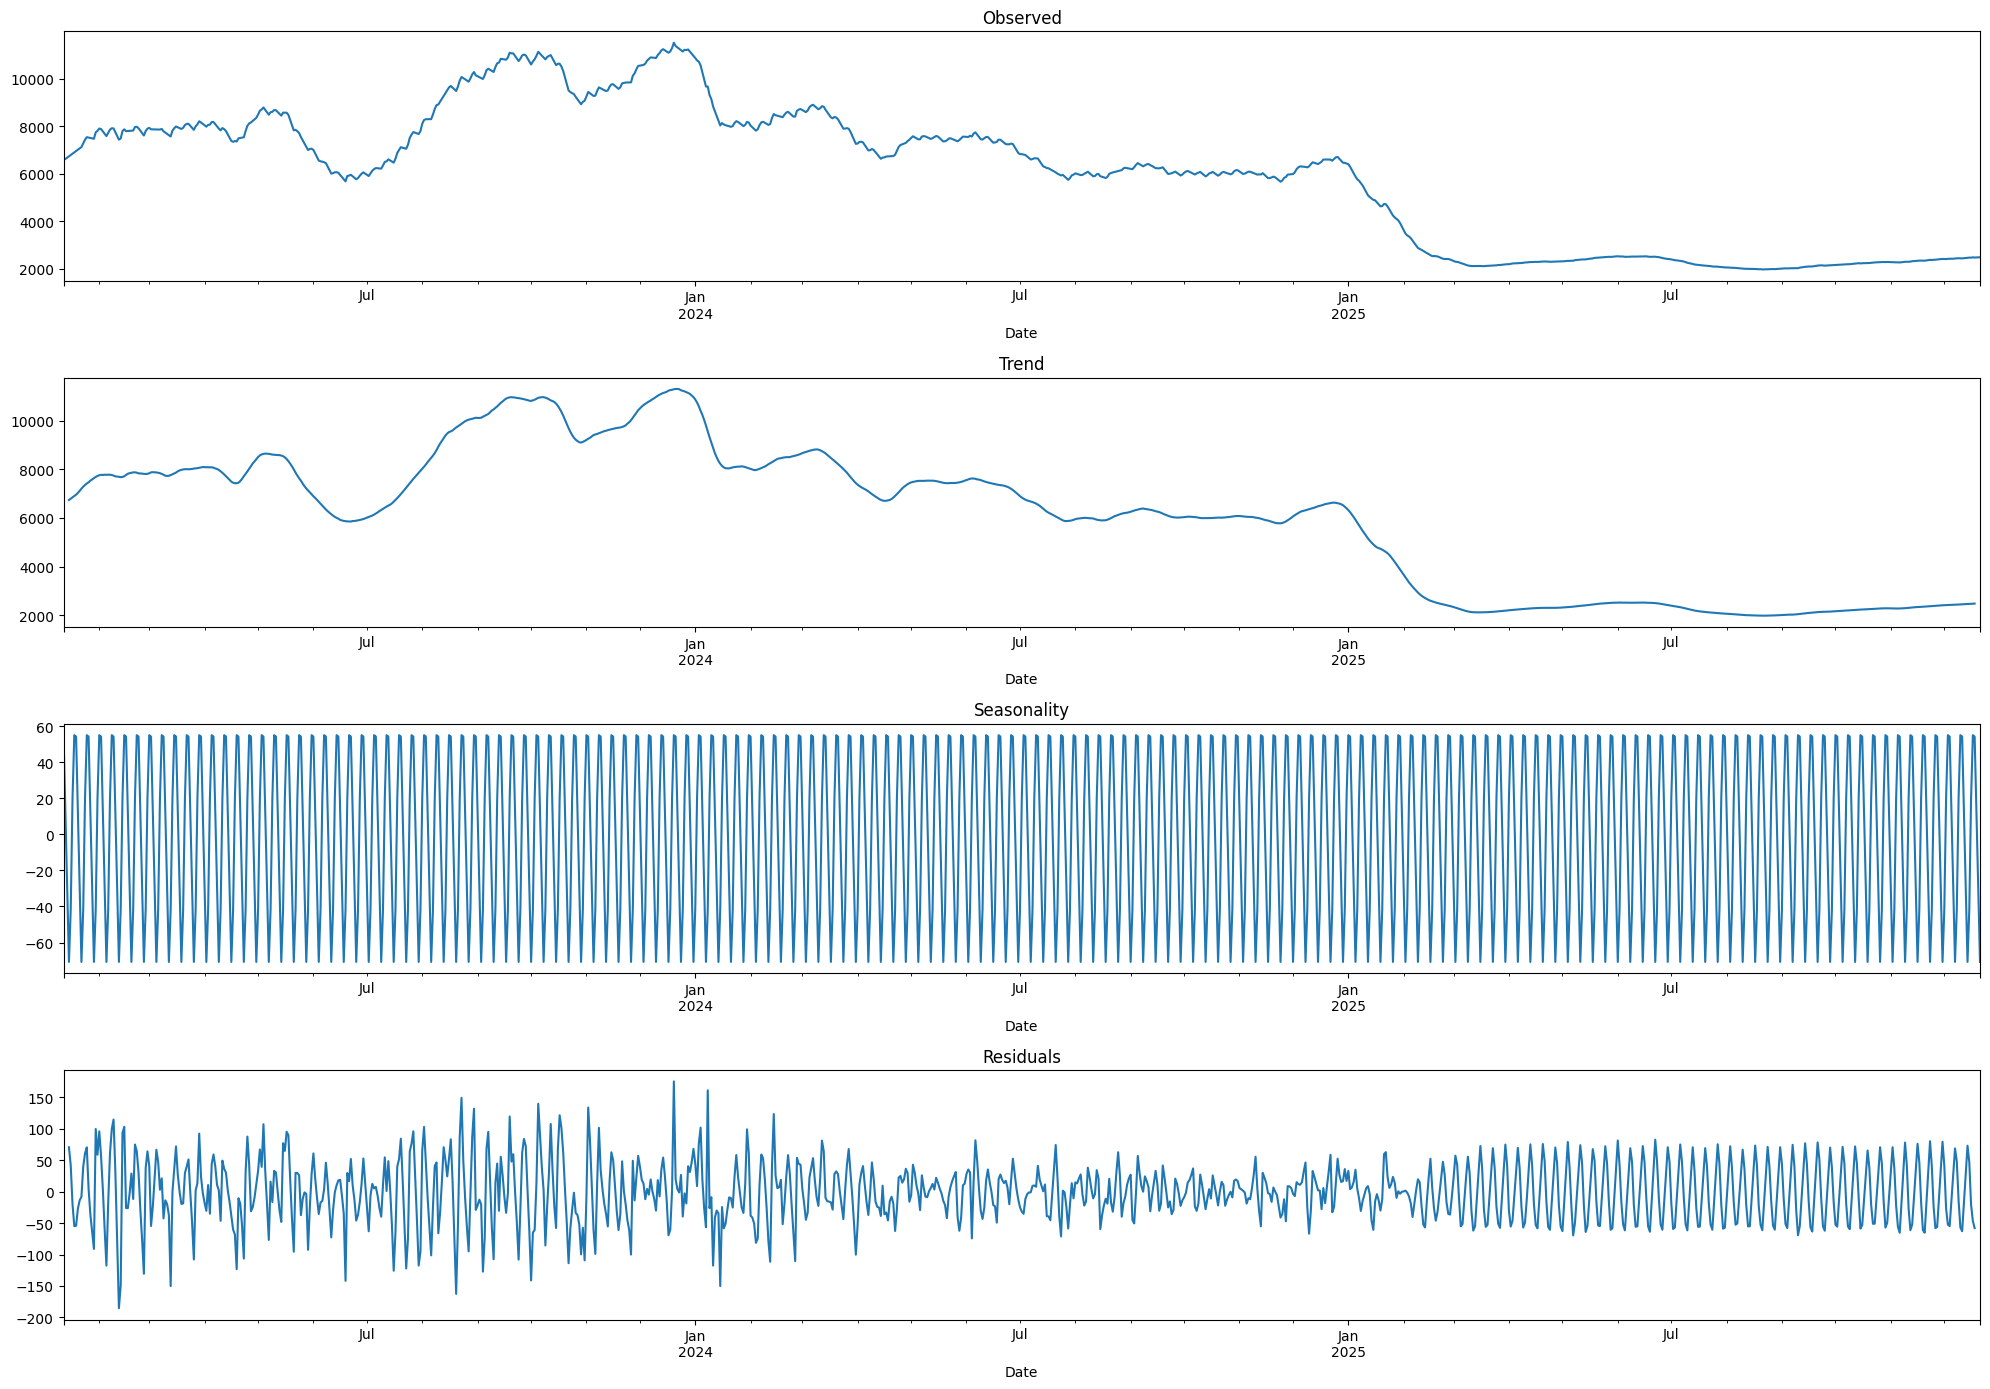

In [5]:
target_col = 'Children in HHS Care'

# Decompose into Trend, Seasonal, and Residual components
decomposition = seasonal_decompose(df_daily[target_col], model='additive', period=7)

# Plotting
fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(20, 14))
decomposition.observed.plot(ax=ax1, title='Observed')
decomposition.trend.plot(ax=ax2, title='Trend')
decomposition.seasonal.plot(ax=ax3, title='Seasonality')
decomposition.resid.plot(ax=ax4, title='Residuals')
plt.tight_layout()
plt.show()

# 1️⃣ Observed (Top Panel)

What it shows

The actual number of Children in HHS Care over time.

This is the raw signal = Trend + Seasonality + Noise.

What we see

High levels during 2023–early 2024 (around 8k–11k)

A sharp structural drop in early 2025

Stabilization at a much lower level (~2k–2.5k) afterward

Interpretation

The system experienced a major regime change, likely due to policy, operational shifts, or intake controls.

This is critical — ML models struggle here, SARIMA handles it better.

# 2️⃣ Trend (Second Panel)

What it represents

The long-term direction of children in care

Smooths out daily and weekly fluctuations

What we see

Rising trend through 2023

Peak around late 2023 / early 2024

Gradual decline through 2024

Sharp downward shift in early 2025

Mild recovery / stabilization afterward

Interpretation

The underlying system load has structurally reduced, not just temporarily fluctuated.

This tells stakeholders:

Capacity requirements must be revised downward

Old benchmarks are no longer valid

# 3️⃣ Seasonality (Third Panel)

What it represents

Repeating short-term patterns

You used period=7, so this is weekly seasonality

What we see

Very consistent oscillation

Amplitude roughly ±50–60 children

Pattern remains stable across years

Interpretation

There is a strong weekly operational rhythm:

Intake/discharge activity follows a weekly cycle

Likely driven by:

Court schedules

Administrative processing

Weekend slowdowns

This is excellent for forecasting — it means seasonality is predictable.

# 4️⃣ Residuals (Bottom Panel)

What residuals are

What remains after removing trend and seasonality

Represents:

Random shocks

Unexplained variation

Policy changes

Data noise

What we see

Mostly centered around zero ✅

Higher volatility before 2024

Lower variance after 2025 (system stabilized)

No long-term pattern → good

Interpretation

Most systematic behavior is already captured by trend + seasonality.

In [6]:
# Create Flow-Based Signal (Net Pressure)
# Net Pressure = Inflow (Transfers) - Outflow (Discharges)
df_daily['Net_Pressure'] = df_daily['Children transferred out of CBP custody'] - df_daily['Children discharged from HHS Care']

# Create Lag Features (t-1, t-7, t-14)
df_daily['lag_1'] = df_daily[target_col].shift(1)
df_daily['lag_7'] = df_daily[target_col].shift(7)
df_daily['lag_14'] = df_daily[target_col].shift(14)

# Create Rolling Features (7-day and 14-day)
df_daily['rolling_mean_7'] = df_daily[target_col].shift(1).rolling(window=7).mean()
df_daily['rolling_std_7'] = df_daily[target_col].shift(1).rolling(window=7).std()
df_daily['rolling_mean_14'] = df_daily[target_col].shift(1).rolling(window=14).mean()

# Create Calendar Features
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['month'] = df_daily.index.month
df_daily['is_weekend'] = df_daily.index.dayofweek.isin([5, 6]).astype(int)

# Drop rows with NaNs created by lagging
df_model = df_daily.dropna()

print("Feature Engineering Complete.")
print(df_model[['Children in HHS Care', 'Net_Pressure', 'lag_1', 'rolling_mean_7']].head())

Feature Engineering Complete.
            Children in HHS Care  Net_Pressure   lag_1  rolling_mean_7
Date                                                                  
2023-01-26                7521.5       -177.25  7538.0     7200.771429
2023-01-27                7505.0       -215.50  7521.5     7281.671429
2023-01-28                7488.5       -253.75  7505.0     7352.271429
2023-01-29                7472.0       -292.00  7488.5     7412.571429
2023-01-30                7743.0       -167.00  7472.0     7462.571429


In [7]:
# Define Split Ratio
train_size = int(len(df_model) * 0.8)

# Split Data
train = df_model.iloc[:train_size]
test = df_model.iloc[train_size:]

# Define Target and Features
features = [ 'lag_1', 'lag_7', 'lag_14', 
            'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 
            'day_of_week', 'month', 'is_weekend']
target = 'Children in HHS Care'

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

print(f"Training Range: {train.index.min().date()} to {train.index.max().date()}")
print(f"Testing Range: {test.index.min().date()} to {test.index.max().date()}")

Training Range: 2023-01-26 to 2025-05-22
Testing Range: 2025-05-23 to 2025-12-21


In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [9]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Define SARIMA (p,d,q) x (P,D,Q,s)
# Using (1,1,1) x (1,1,1,7) as a robust baseline for daily data with weekly seasonality
model_sarima = SARIMAX(train[target], 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 7),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

# Fit Model
sarima_fit = model_sarima.fit(disp=False)

# Forecast
# We forecast strictly over the test index
sarima_pred = sarima_fit.predict(start=len(train), end=len(train) + len(test) - 1, dynamic=False)
sarima_pred.index = test.index

print("SARIMA Model Trained and Forecast Generated.")

SARIMA Model Trained and Forecast Generated.


In [13]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Initialize Models
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
gb_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, random_state=42)

# Fit Models
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)

# Generate Predictions
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

# Convert to Series for easy plotting
rf_pred_series = pd.Series(rf_pred, index=test.index)
gb_pred_series = pd.Series(gb_pred, index=test.index)

print("ML Models (Random Forest & Gradient Boosting) Trained.")

ML Models (Random Forest & Gradient Boosting) Trained.


In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Standard Metrics
mae_rf = mean_absolute_error(y_test, rf_pred_series)
rmse_rf = np.sqrt(mean_squared_error(y_test, rf_pred_series))
mape_rf = np.mean(np.abs((y_test - rf_pred_series) / y_test)) * 100
r2_rf = r2_score(y_test, rf_pred_series) 

# Horizon Metrics (Short Term vs Long Term)
# Short Term: First 7 days
st_true = y_test.iloc[:7]
st_pred_rf = rf_pred_series[:7]
st_mape_rf = np.mean(np.abs((st_true - st_pred_rf) / st_true)) * 100

# Long Term: Day 8 onwards
lt_true = y_test.iloc[7:]
lt_pred_rf = rf_pred_series[7:]
lt_mape_rf = np.mean(np.abs((lt_true - lt_pred_rf) / lt_true)) * 100

# 2. Gradient Boosting Evaluation
mae_gb = mean_absolute_error(y_test, gb_pred_series)
rmse_gb = np.sqrt(mean_squared_error(y_test, gb_pred_series))
mape_gb = np.mean(np.abs((y_test - gb_pred_series) / y_test)) * 100
r2_gb = r2_score(y_test, gb_pred_series)  # <--- Added R2

# Horizon Metrics
st_pred_gb = gb_pred_series[:7]
st_mape_gb = np.mean(np.abs((st_true - st_pred_gb) / st_true)) * 100

lt_pred_gb = gb_pred_series[7:]
lt_mape_gb = np.mean(np.abs((lt_true - lt_pred_gb) / lt_true)) * 100


# 3. Create Comparison Table
evaluation_data = {
    'Model': ['Random Forest', 'Gradient Boosting'],
    'MAE': [mae_rf, mae_gb],
    'RMSE': [rmse_rf, rmse_gb],
    'MAPE (%)': [mape_rf, mape_gb],
    'R2 Score': [r2_rf, r2_gb],  
    'Short-Term Error (7 Days) %': [st_mape_rf, st_mape_gb],
    'Long-Term Error (8+ Days) %': [lt_mape_rf, lt_mape_gb]
}

df_results = pd.DataFrame(evaluation_data).round(4) 

print(">>> Model Performance Comparison")
print(df_results)

>>> Model Performance Comparison
               Model      MAE     RMSE  MAPE (%)  R2 Score  \
0      Random Forest  40.5460  62.8341    1.9212    0.8763   
1  Gradient Boosting  58.7886  79.3318    2.7694    0.8028   

   Short-Term Error (7 Days) %  Long-Term Error (8+ Days) %  
0                       1.1899                       1.9460  
1                       1.3051                       2.8192  


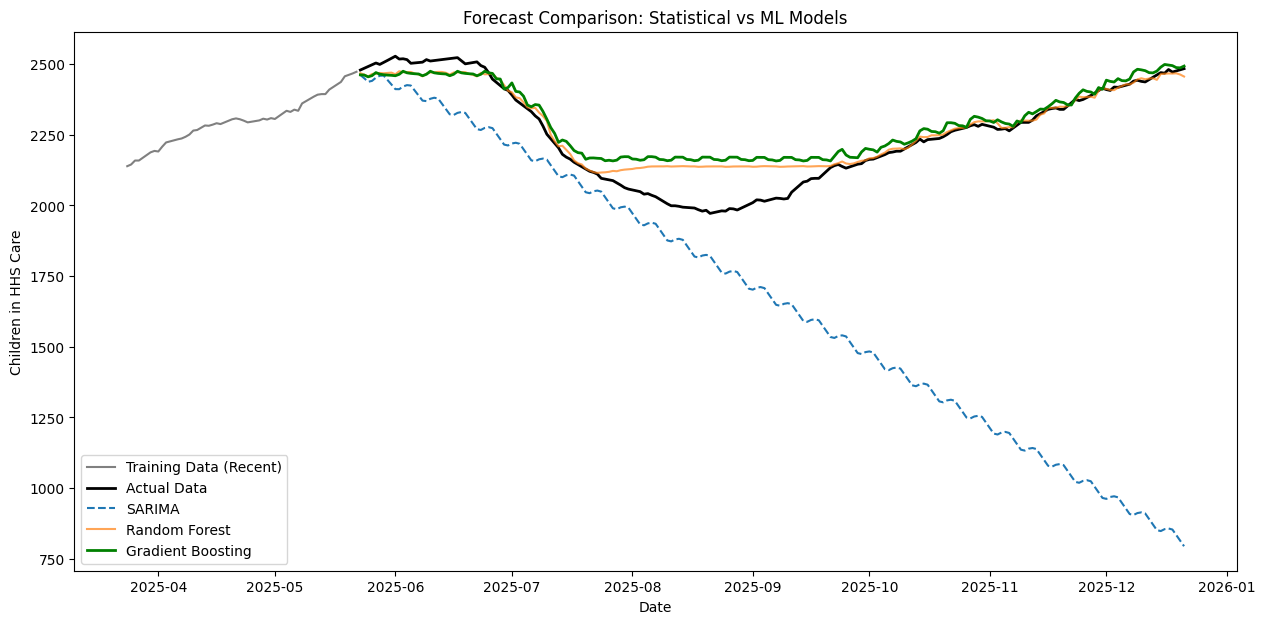

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(train.index[-60:], train[target].iloc[-60:], label='Training Data (Recent)', color='gray')
plt.plot(test.index, y_test, label='Actual Data', color='black', linewidth=2)
plt.plot(test.index, sarima_pred, label='SARIMA', linestyle='--')
plt.plot(test.index, rf_pred_series, label='Random Forest', alpha=0.7)
plt.plot(test.index, gb_pred_series, label='Gradient Boosting', color='green', linewidth=2)
# plt.plot(test.index, lr_pred, Label='Liner Regression', color='red', linewidth=2 )

plt.title('Forecast Comparison: Statistical vs ML Models')
plt.xlabel('Date')
plt.ylabel('Children in HHS Care')
plt.legend()
plt.show()

The actual data shows a decline followed by stabilization and recovery.

Gradient Boosting tracks this pattern most accurately, adapting well to trend changes.

Random Forest captures the general direction but reacts more slowly at turning points.

SARIMA continues a strong downward trend and fails to capture recovery, indicating over-extrapolation of past declines.